In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import r2_score, mean_absolute_error, make_scorer
from sklearn.base import clone

In [36]:
df = pd.read_csv('../../../data/preprocessed/selected_features_dataset_V2.csv')
X = df.drop('price_per_m2', axis=1)
y = df['price_per_m2']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [37]:
def gap_scorer(estimator, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    estimator = clone(estimator)  # Avoid estimator reuse
    estimator.fit(X_train, y_train)
    
    train_r2 = r2_score(y_train, estimator.predict(X_train))
    val_r2 = r2_score(y_val, estimator.predict(X_val))
    gap = abs(train_r2 - val_r2)
    
    return 0.7 * val_r2 - 0.3 * gap

In [38]:
base_models = [
    ('rf', RandomForestRegressor(
        n_estimators= 100, 
        min_samples_split= 10, 
        min_samples_leaf= 4,
        max_samples = 0.8,
        max_features= 0.8, 
        max_depth= 5, 
        ccp_alpha= 0.0, 
        bootstrap= True
    )),
    ('gb', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        min_samples_leaf=5,
        subsample=0.8,
        validation_fraction=0.2,
        n_iter_no_change=5,
        random_state=42
    )),
    ('svr', make_pipeline(
        RobustScaler(),
        SVR(C=100,degree=2, epsilon=0.5, gamma='auto', kernel='rbf')
    ))
]

In [39]:
stacking_regressor = StackingRegressor(
    estimators=base_models,
    final_estimator=RidgeCV(alphas=[0.1, 1.0, 10.0]),
    cv=5,
    passthrough=False,
    n_jobs=-1
)

In [40]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name=""):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    return {
        'Model': model_name,
        'Train R2': r2_score(y_train, train_pred),
        'Test R2': r2_score(y_test, test_pred),
        'R2 Gap': r2_score(y_train, train_pred) - r2_score(y_test, test_pred),
        'Train MAE': mean_absolute_error(y_train, train_pred),
        'Test MAE': mean_absolute_error(y_test, test_pred),
        'MAE Gap': mean_absolute_error(y_train, train_pred) - mean_absolute_error(y_test, test_pred)
    }

In [41]:
results = []
for name, model in base_models:
    results.append(evaluate_model(model, X_train, y_train, X_test, y_test, name.upper()))
    
stack_results = evaluate_model(stacking_regressor, X_train, y_train, X_test, y_test, "STACKING")
results.append(stack_results)

In [42]:
gap_df = pd.DataFrame(results)
print("\nModel Performance Comparison:")
print(gap_df[['Model', 'Train R2', 'Test R2', 'R2 Gap', 'Train MAE', 'Test MAE', 'MAE Gap']])


Model Performance Comparison:
      Model  Train R2   Test R2    R2 Gap   Train MAE    Test MAE    MAE Gap
0        RF  0.883787  0.869806  0.013981  399.501929  414.491095 -14.989166
1        GB  0.909385  0.882981  0.026404  352.911765  385.895601 -32.983835
2       SVR  0.829967  0.825718  0.004249  455.994393  454.141597   1.852796
3  STACKING  0.914380  0.885439  0.028941  345.017676  380.613942 -35.596266


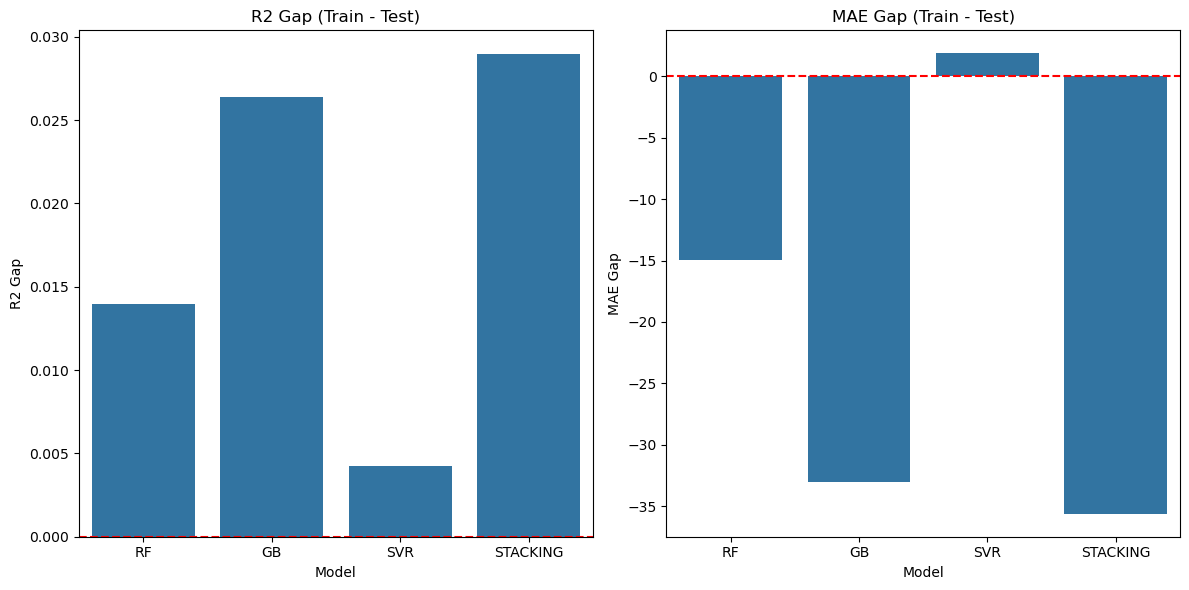

In [43]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='R2 Gap', data=gap_df)
plt.axhline(0, color='red', linestyle='--')
plt.title('R2 Gap (Train - Test)')

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='MAE Gap', data=gap_df)
plt.axhline(0, color='red', linestyle='--')
plt.title('MAE Gap (Train - Test)')
plt.tight_layout()
plt.show()


In [44]:
print("\nOptimized Stacking Performance:")
print(f"Train R2: {stack_results['Train R2']:.4f}")
print(f"Test R2: {stack_results['Test R2']:.4f}")
print(f"R2 Gap: {stack_results['R2 Gap']:.4f}")
print(f"Train MAE: {stack_results['Train MAE']:.2f}")
print(f"Test MAE: {stack_results['Test MAE']:.2f}")
print(f"MAE Gap: {stack_results['MAE Gap']:.2f}")


Optimized Stacking Performance:
Train R2: 0.9144
Test R2: 0.8854
R2 Gap: 0.0289
Train MAE: 345.02
Test MAE: 380.61
MAE Gap: -35.60
